## Bag of Words
Amaç:
- Metin temsili: metin listesi -> sayısal vektörlere çevir
- sklearn CountVectorizer: kelimelerin kaç defa geçtiğini sayar ve vektör temsiline dönüştürürür

Sonuç:
- kelime kümesi (vocabulary)
- her metin listesi sayısal vektörler ile temsil edilecek

In [116]:
from sklearn.feature_extraction.text import CountVectorizer

In [117]:
# örnek metinlerden oluşan küçük bir veri seti oluştur.
dokumanlar = [
    "kedi bahçede",
    "kedi evde"
]

In [118]:
# count vektorizer nesnesini oluştur
kelime_sayac = CountVectorizer()

In [119]:
#dokumanları sayısal vektörlere çevir (bag of words uygula)
dokuman_vektorleri = kelime_sayac.fit_transform(dokumanlar)
dokuman_vektorleri

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 4 stored elements and shape (2, 3)>

In [120]:
# count vektorizer tarafından bulunan kelime listesi yan vocabulary oluşturalım print ettirelim
kelime_kumesi = kelime_sayac.get_feature_names_out()
print(f"Kelime Kümesi: {kelime_kumesi}")

Kelime Kümesi: ['bahçede' 'evde' 'kedi']


In [121]:
# vektor temsiline bakalım
vektor_temsili = dokuman_vektorleri.toarray()
print(f"Vektör temsili: \n{vektor_temsili}")

Vektör temsili: 
[[1 0 1]
 [0 1 1]]


## Bag of Words
Amaç:
- IMDB film yorumları içeren veri seti ile bag of words
- csv dosyasından veriyi oku (IMDB Dataset.csv)
- text cleaning (küçük büyük harf çevirme, rakam ve özel karakterlerden kurtulma)
- metinleri sayısal vektörlere dönüştür
- kelime frekanslarını hesapla ve en sık geçen 5 kelimeyi listele

In [122]:
# gerekli kütüphanelerin içeri aktarılması
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer # bag of words
import re # regular expression (veri temizleme)
from collections import Counter

In [123]:
# read.csv
veri = pd.read_csv("/content/sample_data/IMDB Dataset.csv")
veri.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [124]:
# yorumları (reivew) al
yorumlar = veri["review"]
yorumlar

,review
0,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...
2,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is..."
...,...
49995,I thought this movie did a down right good job...
49996,"Bad plot, bad dialogue, bad acting, idiotic di..."
49997,I am a Catholic taught in parochial elementary...
49998,I'm going to have to disagree with the previou...


In [125]:
#etiketleri (sentiment) al
etiketler = veri["sentiment"]
etiketler

,sentiment
0,positive
1,positive
2,positive
3,negative
4,positive
...,...
49995,positive
49996,negative
49997,negative
49998,negative


In [126]:
# metin temizleme
def metin_temizle(metin):
  #tüm harfleri küçük harfe çevir
  metin = metin.lower()

  #rakamları kaldır
  metin = re.sub(r"\d+", "",metin)

  #özel karakterleri kaldır
  metin = re.sub(r"[^\w\s]","",metin)

  #çok kısa kelimeleri yani 2 karakterden kısa olanları kaldır
  metin = " ".join([kelime for kelime in metin.split() if len(kelime) > 2])

  #temizlenmiş veriyi return et
  return metin

In [127]:
#yorumları temizleme işlemi uygula
temizlenmiş_yorumlar = [metin_temizle(y) for y in yorumlar]

In [128]:
# bow
bow_modeli = CountVectorizer()

In [129]:
# ilk 75 yorumu sayısal vektörlere çevirelim
yorum_vektorleri = bow_modeli.fit_transform(temizlenmiş_yorumlar[:75])

In [130]:
# vocabulary (kelime kümesi)
kelime_kumesi = bow_modeli.get_feature_names_out()
kelime_kumesi


array(['abbot', 'abetted', 'abiding', ..., 'zone', 'zooms', 'zwick'],
      dtype=object)

In [131]:
vektor_temsili = yorum_vektorleri.toarray()
vektor_temsili

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [132]:
# her kelimenin toplam kaç adet geçtiği
kelime_sayilari = yorum_vektorleri.sum(axis=0).A1

In [133]:
#kelimeler ile frekansları bir sözlükte eşleştirelim
kelime_frekansi = dict(zip(kelime_kumesi, kelime_sayilari))
en_cok_gecen_5_kelime = Counter(kelime_frekansi).most_common(5)
en_cok_gecen_5_kelime

[('the', np.int64(1033)),
 ('and', np.int64(463)),
 ('this', np.int64(185)),
 ('that', np.int64(174)),
 ('with', np.int64(132))]

## TF-IDF
Örnek birkaç cümle üzerinden TF-IDF uygulayarak cümleleri vektörleştirmek

Adımlar:
1. Küçük bir belge oluştur
2. TF-IDF vektörizer ile belgeleri sayısal vektörlere dönüştür
3. Kelime kümesini oluştur
4. Belgelerin tf-idf vektör temsillerini elde edelim
5. Tüm belgeler için kelimelerin ortalama tf-idf değerlerini hesaplayalım

In [134]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

In [135]:
# örnek belgeleri tanımla
belgeler = [
    "Köpek çok tatlı bir hayvandır",
    "Köpek ve kuşlar çok tatlı hayvanlardır",
    "İnekler süt üretirler"
]

In [136]:
# tf idf modeli oluştur
tfidf_modeli = TfidfVectorizer()

In [137]:
# belgeleri sayısal vektörlere dönüştür
belge_vektorleri = tfidf_modeli.fit_transform(belgeler)

In [138]:
# kelime kümesini yani vocab oluştur
kelime_kumesi = tfidf_modeli.get_feature_names_out()

In [139]:
# belgelerin tf idf değerlerini numpy formatına çevir
vektor_temsili = belge_vektorleri.toarray()

In [140]:
vektor_temsili

array([[0.51741994, 0.51741994, 0.        , 0.        , 0.3935112 ,
        0.        , 0.        , 0.3935112 , 0.        , 0.3935112 ,
        0.        ],
       [0.        , 0.        , 0.45954803, 0.45954803, 0.34949812,
        0.        , 0.        , 0.34949812, 0.45954803, 0.34949812,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.57735027, 0.57735027, 0.        , 0.        , 0.        ,
        0.57735027]])

In [141]:
# bunları okunabilir hale getir
df_tf_idf = pd.DataFrame(vektor_temsili, columns=kelime_kumesi)
df_tf_idf

,bir,hayvandır,hayvanlardır,kuşlar,köpek,nekler,süt,tatlı,ve,çok,üretirler
0,0.51742,0.51742,0.000000,0.000000,0.393511,0.00000,0.00000,0.393511,0.000000,0.393511,0.00000
1,0.00000,0.00000,0.459548,0.459548,0.349498,0.00000,0.00000,0.349498,0.459548,0.349498,0.00000
2,0.00000,0.00000,0.000000,0.000000,0.000000,0.57735,0.57735,0.000000,0.000000,0.000000,0.57735


In [142]:
# her kelimenin belgeler arasındaki ortalama tf idf değerlerini hesapla
ortalama_tf_idf = df_tf_idf.mean(axis=0)
ortalama_tf_idf

,0
bir,0.172473
hayvandır,0.172473
hayvanlardır,0.153183
kuşlar,0.153183
köpek,0.247670
nekler,0.192450
süt,0.192450
tatlı,0.247670
ve,0.153183
çok,0.247670


## Words Embedding (Kelime Gömme)
Küçük bir veri seti ile word embedding yani kelime gömme gerçekleştirme
- word2vec: google
- fasttext: meta(facebook)

Adımlar:
1. örnek cümle veri seti oluşturma
2. preprocessing: cümleleri tokenlara çevirme
3. word2vec ve fasttext modelleri eğitilir
4. kelime vektörleri 2 boyutlu olarak görselleştirilir

In [143]:
pip install gensim

In [144]:
# gerekli kütüphaneleri içeri aktar
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models import Word2Vec, FastText
from gensim.utils import simple_preprocess

In [145]:
# örnek veri seti
cumleler = [
    "Köpek çok tatlı bir hayvandır.",
    "Köpekler evcil hayvanlardır.",
    "Kediler genellikle bağımsız olmayı severler.",
    "Köpekler dost canlısı hayvanlardır",
    "Hayvanlar insanlara arkadaş olabilir",
    "Türkiye'nin başkenti Ankara'dır.",
    "Türkiye'de Ankara ve Gaziantep'in yemekleri çok güzel."
  ]

In [146]:
# cümleleri tokenize et
tokenize_cumleler = [simple_preprocess(c) for c in cumleler]
tokenize_cumleler

[['köpek', 'çok', 'tatlı', 'bir', 'hayvandır'],
 ['köpekler', 'evcil', 'hayvanlardır'],
 ['kediler', 'genellikle', 'bağımsız', 'olmayı', 'severler'],
 ['köpekler', 'dost', 'canlısı', 'hayvanlardır'],
 ['hayvanlar', 'insanlara', 'arkadaş', 'olabilir'],
 ['türkiye', 'nin', 'başkenti', 'ankara', 'dır'],
 ['türkiye',
  'de',
  'ankara',
  've',
  'gaziantep',
  'in',
  'yemekleri',
  'çok',
  'güzel']]

In [147]:
# word2vec
word2vec_model = Word2Vec(sentences=tokenize_cumleler,
                          vector_size=2, # doğrudan iki boyutlu vektor
                          window=5, # model bağlamı öğrenirken etrafındaki kaç kelimeye bakacağını belirler
                          min_count=1, # bir kelimenin modele dahil olabilmesi için en az kaç kez geçtiğini belirler
                          sg=0 # 0: CBOW (Continous Bag of Words) kelimenin bağlamından kelimeyi tahmin eder, 1:skip gram
                          )

In [148]:
# fast text
fasttext_model = FastText(
    sentences = tokenize_cumleler,
    vector_size = 2,
    window = 5,
    min_count = 1,
    sg = 0
)

In [149]:
def plot_word_embeddings(model,baslik):
  kelime_vektor = model.wv # wv: word vektor
  kelimeler = list(kelime_vektor.index_to_key)
  vektorler = [kelime_vektor[w] for w in kelimeler]

  plt.figure(figsize= (8,5))
  plt.scatter([v[0] for v in vektorler], [v[1] for v in vektorler])

  for i, kelime in enumerate(kelimeler):
    plt.text(vektorler[i][0], vektorler[i][1],kelime,fontsize=12)

  plt.title(baslik)
  plt.xlabel("Bileşen 1")
  plt.ylabel("Bileşen 2")
  plt.show()

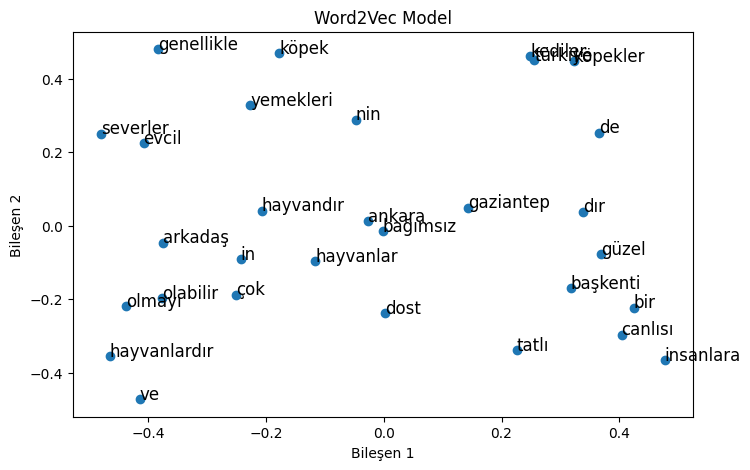

In [150]:
plot_word_embeddings(word2vec_model,"Word2Vec Model")

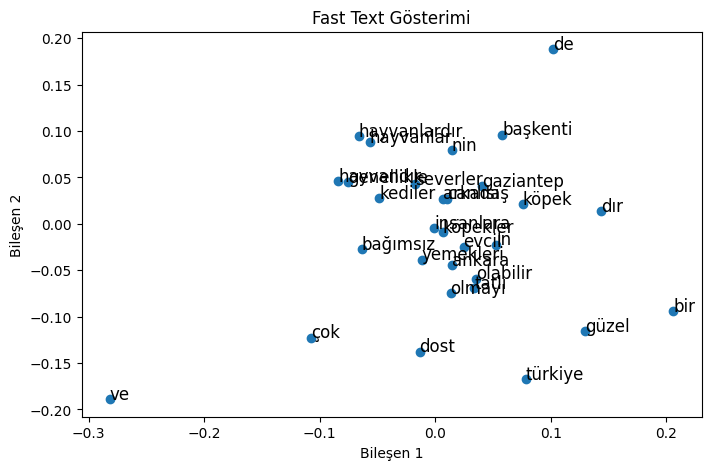

In [151]:
plot_word_embeddings(fasttext_model, "Fast Text Gösterimi")

## Word Embedding IMDB Veri Seti
IMDB film yorumları üzerinden FastText tabanlı kelime vektörleri üretelim ve bunu doğrudan 2 boyutlu görselleştirme

Adımlar:
1. Veri seti yükleme
2. Metinleri temizleme (küçük harf dönüşümü, özel karakterler, kısa kelimelerin kaldırılması, stopwords silme)
3. Tokenizasyon
4. FastText modeli eğitimi
5. 2D görselleştirme

In [152]:
# gerekli kütüphanelerin içeri aktarılması
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from gensim.models import FastText
from gensim.utils import simple_preprocess

In [153]:
# stop words indir
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [154]:
# veri setini yükle
veri = pd.read_csv("/content/sample_data/IMDB Dataset.csv")
yorumlar = veri["review"]

In [155]:
# metin temizleme
def metin_temizle(metin):
  metin = metin.lower() #küçük harfe çevir
  metin = re.sub(r"\d+","",metin) # sayıları kaldır
  metin = re.sub(r"[^\w\s]","",metin) # noktalama ve özel karakterleri kaldır
  kelimeler = metin.split()

  #stop words kaldır
  kelimeler = [k for k in kelimeler if k not in stop_words]

  # kısa kelimeleri çıkart
  kelimeler = [k for k in kelimeler if len(k) > 2]
  return " ".join(kelimeler)

In [156]:
# yorumları temizle
temiz_yorumlar = [metin_temizle(y) for y in yorumlar]

In [157]:
# tokenizasyon
tokenize_yorumlar = [simple_preprocess(y) for y in temiz_yorumlar]

In [158]:
# fast text
fasttext_model = FastText(
    sentences = tokenize_yorumlar,
    vector_size = 2, #doğrudan 2 boyutlu embedding
    window = 5,
    min_count = 3, # çok az geçen kelimeleri alma
    sg = 0 # 1: skip gram
)

In [159]:
# kelime vektörlerini al
kelime_vektorleri = fasttext_model.wv
kelimeler = list(kelime_vektorleri.index_to_key)[:100]
vektorler = [kelime_vektorleri[w] for w in kelimeler]

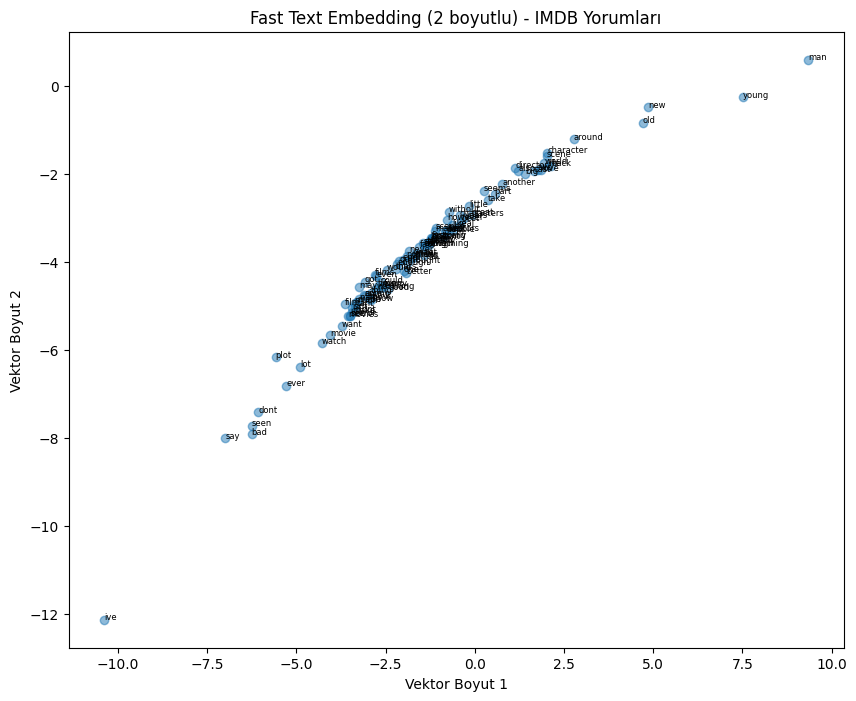

In [160]:
# görselleştirme
plt.figure(figsize= (10,8))
plt.scatter(
    [v[0] for v in vektorler],
    [v[1] for v in vektorler],
    alpha = 0.5
)
for i,kelime in enumerate(kelimeler):
  plt.text(vektorler[i][0], vektorler[i][1],kelime,fontsize=6)

plt.title("Fast Text Embedding (2 boyutlu) - IMDB Yorumları")
plt.xlabel("Vektor Boyut 1")
plt.ylabel("Vektor Boyut 2")
plt.show()